In [1]:
!pip install shap lime scikit-image -q

In [2]:
import os, io, random, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import scipy.io as sio
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
import matplotlib.cm as mcm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.models import resnet101, ResNet101_Weights
from PIL import Image

import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries, quickshift as qs_seg
from skimage.transform import resize as sk_resize

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")


PyTorch : 2.10.0+cu128
CUDA    : True


In [3]:
# ── Dataset ───────────────────────────────────────────────────────────────────
DATA_DIR   = "/kaggle/input/datasets/userisakid/augmented-figshare-dataset"
TEST_DIR   = os.path.join(DATA_DIR, "test")
MODEL_PATH = "/kaggle/input/notebooks/userisakid/resnet101-v1/best_resnet101.pth"

# ── Classes ───────────────────────────────────────────────────────────────────
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 224

# ── ImageNet stats ────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── XAI hyper-parameters ──────────────────────────────────────────────────────
N_PER_CLASS       = 2      # images per class from TEST set
LIME_NUM_SAMPLES  = 2000   # LIME perturbations
LIME_NUM_FEATURES = 12     # top superpixels shown
LIME_BATCH_SIZE   = 64
SHAP_BG_SIZE      = 40     # background images for SHAP explainer

# ── Overlap analysis threshold ────────────────────────────────────────────────
SALIENCY_THRESH = 0.50     # binarise saliency maps at this percentile

print(f"Device      : {DEVICE}")
print(f"Classes     : {CLASS_NAMES}")
print(f"Test dir    : {TEST_DIR}")


Device      : cuda
Classes     : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Test dir    : /kaggle/input/datasets/userisakid/augmented-figshare-dataset/test


In [4]:
def load_mat_data(src):
    """
    Load image AND tumorMask from a .mat file.
    Returns: img_u8 (H,W) uint8, mask (H,W) bool
    Handles both old scipy format and new HDF5 v7.3.
    src: filepath str OR raw bytes
    """
    open_fn = (lambda: sio.loadmat(src)) if isinstance(src, str) \
              else (lambda: sio.loadmat(io.BytesIO(src)))

    h5_fn = (lambda: h5py.File(src, 'r')) if isinstance(src, str) \
            else (lambda: h5py.File(io.BytesIO(src), 'r'))

    mask = None

    try:
        mat = open_fn()
        img_raw = mat['cjdata']['image'][0, 0].astype(np.float32)

        if 'tumorMask' in mat['cjdata'].dtype.names:
            mask = mat['cjdata']['tumorMask'][0, 0].astype(bool)

    except Exception:
        with h5_fn() as f:
            img_raw = np.array(f['cjdata']['image']).astype(np.float32).T

            if 'tumorMask' in f['cjdata']:
                mask = np.array(f['cjdata']['tumorMask']).astype(bool).T

    mn, mx = img_raw.min(), img_raw.max()
    img_u8 = ((img_raw - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)

    return img_u8, mask


def mat_to_pil(src, filename=None):
    """
    Load .mat / .png / .jpg → PIL RGB
    (224x224 NOT applied here)
    """
    fname = (src if isinstance(src, str) else (filename or '')).lower()

    if fname.endswith('.mat') or isinstance(src, bytes):
        img_u8, _ = load_mat_data(src)
        return Image.fromarray(img_u8, 'L').convert('RGB')

    return Image.open(src).convert('RGB')


def load_mat_mask(src, filename=None):
    """
    Return (pil_rgb, mask_bool_HW or None)
    """
    fname = (src if isinstance(src, str) else (filename or '')).lower()

    if fname.endswith('.mat') or isinstance(src, bytes):
        img_u8, mask = load_mat_data(src)
        pil = Image.fromarray(img_u8, 'L').convert('RGB')
        return pil, mask

    return Image.open(src).convert('RGB'), None


def build_file_list(split_dir):
    file_list = []

    for label_idx, cls in enumerate(CLASS_NAMES):
        cls_dir = os.path.join(split_dir, cls)

        if not os.path.isdir(cls_dir):
            continue

        for fname in sorted(os.listdir(cls_dir)):
            if fname.lower().endswith(('.mat', '.png', '.jpg', '.jpeg')):
                file_list.append((os.path.join(cls_dir, fname), label_idx))

    return file_list


infer_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


def denormalize(tensor):
    mean = np.array(IMAGENET_MEAN).reshape(3,1,1)
    std  = np.array(IMAGENET_STD).reshape(3,1,1)

    img = tensor.cpu().numpy() * std + mean
    return np.clip(img, 0, 1).transpose(1,2,0)


print("Data helpers ready.")

Data helpers ready.


In [5]:
def build_model():
    m = resnet101(weights=ResNet101_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def get_target_layer(model):
    return model.layer4[-1].conv3   # last bottleneck conv — best for Grad-CAM

model        = build_model()
target_layer = get_target_layer(model)

if os.path.exists(MODEL_PATH):
    state = torch.load(MODEL_PATH, map_location=DEVICE)
    if isinstance(state, dict):
        for key in ('model_state_dict', 'state_dict', 'model'):
            if key in state:
                state = state[key]
                print(f'  (extracted key "{key}" from checkpoint)')
                break
    model.load_state_dict(state, strict=False)
    print(f'Loaded weights from {MODEL_PATH}')
else:
    print(f'⚠  {MODEL_PATH} not found — using pretrained ImageNet weights only.')

model = model.to(DEVICE)
model.eval()
print(f'Model ready on {DEVICE}')
print(f'Grad-CAM target layer: {target_layer}')


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 197MB/s]


Loaded weights from /kaggle/input/notebooks/userisakid/resnet101-v1/best_resnet101.pth
Model ready on cuda
Grad-CAM target layer: Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [6]:
test_files = build_file_list(TEST_DIR)
per_class  = {i: [] for i in range(NUM_CLASSES)}
for fpath, lbl in test_files:
    per_class[lbl].append(fpath)

print(f'Test files total: {len(test_files)}')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:<15s}: {len(per_class[i])} files')


# ── Balanced sample function ──────────────────────────────────────────────────
def sample_balanced(n_per_class=N_PER_CLASS):
    sampled = []
    for i, cls in enumerate(CLASS_NAMES):
        picks = random.sample(per_class[i], min(n_per_class, len(per_class[i])))
        sampled.extend([(p, i) for p in picks])
    random.shuffle(sampled)
    return sampled


# ── Build SHAP background ─────────────────────────────────────────────────────
BG_PER_CLASS = SHAP_BG_SIZE // NUM_CLASSES

_bg_paths = []
for cls_idx in range(NUM_CLASSES):
    pool  = per_class[cls_idx]
    picks = random.sample(pool, min(BG_PER_CLASS, len(pool)))
    _bg_paths.extend(picks)
random.shuffle(_bg_paths)

_bg_tensors = torch.stack([
    infer_tf(mat_to_pil(p)) for p in _bg_paths
]).to(DEVICE)

shap_explainer = shap.GradientExplainer(model, _bg_tensors)

print(f'\nSHAP background: {len(_bg_paths)} images')
print('Ready.')


Test files total: 560
  glioma         : 140 files
  meningioma     : 140 files
  no_tumor       : 140 files
  pituitary      : 140 files

SHAP background: 40 images
Ready.


In [7]:
def run_gradcam(pil_rgb):
    gradients, activations = {}, {}

    fwd = target_layer.register_forward_hook(
        lambda m, i, o: activations.update({'v': o.detach()}))
    bwd = target_layer.register_full_backward_hook(
        lambda m, gi, go: gradients.update({'v': go[0].detach()}))

    inp    = infer_tf(pil_rgb).unsqueeze(0).to(DEVICE)
    output = model(inp)
    probs  = F.softmax(output, dim=1).squeeze().detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))

    model.zero_grad()
    output[0, pred_idx].backward()

    w   = gradients['v'].mean(dim=[2,3], keepdim=True)
    cam = F.relu((w * activations['v']).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, (IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    fwd.remove(); bwd.remove()
    return cam, pred_idx, probs


def overlay_cam(img_np, heatmap, alpha=0.50):
    h     = plt.cm.jet(heatmap)[..., :3]
    img_f = img_np.astype(np.float32) / 255.
    return np.clip(alpha * h + (1 - alpha) * img_f, 0, 1)

print("Grad-CAM ready.")


Grad-CAM ready.


In [8]:
def run_shap(pil_rgb):
    t         = infer_tf(pil_rgb).unsqueeze(0).to(DEVICE)
    shap_vals = shap_explainer.shap_values(t)

    if isinstance(shap_vals, list):
        shap_arr = np.stack(shap_vals, axis=-1)
    else:
        shap_arr = shap_vals

    with torch.no_grad():
        probs = F.softmax(model(t), dim=1).squeeze().cpu().numpy()
    pred_idx = int(np.argmax(probs))

    sv       = shap_arr[0, :, :, :, pred_idx]   # (C,H,W)
    shap_map = sv.mean(axis=0)                   # (H,W)
    return shap_map, pred_idx, probs


def make_shap_rgb(img_np, shap_map, alpha=0.55):
    vmax = np.abs(shap_map).max() + 1e-8
    norm = shap_map / vmax                      # [-1,1]
    pos  = np.clip( norm, 0, 1)
    neg  = np.clip(-norm, 0, 1)

    # warm=positive, cool=negative
    hot  = plt.cm.Reds(pos)[..., :3]
    cold = plt.cm.Blues(neg)[..., :3]
    heat = np.where(norm[..., None] > 0, hot, cold)

    bg = np.stack([img_np/255.]*3, axis=-1) if img_np.ndim==2 \
         else img_np.astype(np.float32)/255.
    saliency_mask = (np.abs(norm) > 0.25)[..., None]
    out = np.where(saliency_mask, alpha*heat + (1-alpha)*bg, bg)
    return np.clip(out, 0, 1)

print("SHAP ready.")


SHAP ready.


In [9]:
lime_explainer = lime_image.LimeImageExplainer(verbose=False)

def lime_predict_fn(images_np):
    probs_list = []
    for start in range(0, len(images_np), LIME_BATCH_SIZE):
        batch_np = images_np[start:start + LIME_BATCH_SIZE]
        tensors  = torch.stack([
            infer_tf(Image.fromarray(img.astype(np.uint8)))
            for img in batch_np
        ]).to(DEVICE)
        with torch.no_grad():
            probs = F.softmax(model(tensors), dim=1).cpu().numpy()
        probs_list.append(probs)
    return np.concatenate(probs_list, axis=0)


def run_lime(pil_rgb):
    img_r    = pil_rgb.resize((IMG_SIZE, IMG_SIZE))
    img_np   = np.array(img_r)

    with torch.no_grad():
        t     = infer_tf(img_r).unsqueeze(0).to(DEVICE)
        probs = F.softmax(model(t), dim=1).squeeze().cpu().numpy()
    pred_idx = int(np.argmax(probs))

    seg_fn = lambda x: qs_seg(x, kernel_size=2, max_dist=50, ratio=0.2)

    explanation = lime_explainer.explain_instance(
        img_np, lime_predict_fn,
        top_labels      = NUM_CLASSES,
        hide_color      = 0,
        num_samples     = LIME_NUM_SAMPLES,
        batch_size      = LIME_BATCH_SIZE,
        segmentation_fn = seg_fn,
    )
    return explanation, pred_idx, probs, img_np


def get_lime_heatmap(explanation, pred_idx, num_features=LIME_NUM_FEATURES):
    """
    Returns:
      heatmap   – signed (H,W) float
      pos_mask  – boolean (H,W) for top positive superpixels
      lime_overlay – full-image LIME overlay (green tint on selected regions)
    """
    seg  = explanation.segments
    vals = dict(explanation.local_exp[pred_idx])

    # ── signed heatmap ───────────────────────────────────────────────────────
    heatmap = np.zeros(seg.shape, dtype=np.float32)
    for sid, w in vals.items():
        heatmap[seg == sid] = w

    # ── top positive superpixels ─────────────────────────────────────────────
    pos_mask = np.zeros(seg.shape, dtype=bool)
    top_pos  = sorted([(w, s) for s, w in vals.items() if w > 0],
                      reverse=True)[:num_features]
    for _, sid in top_pos:
        pos_mask[seg == sid] = True

    # ── FULL-IMAGE overlay: green tint on selected superpixels ───────────────
    img_np   = (explanation.image * 255).astype(np.uint8)
    base     = img_np.astype(np.float32) / 255.0          # full image [0,1]

    # Green tint on positive superpixels (alpha blend)
    tint          = base.copy()
    green_channel = np.array([0.0, 1.0, 0.2])
    tint[pos_mask] = 0.45 * green_channel + 0.55 * base[pos_mask]

    # Thick green boundary around selected superpixels
    lime_overlay = mark_boundaries(tint, pos_mask.astype(int),
                                   color=(0.05, 0.95, 0.15), mode='thick')
    lime_overlay = np.clip(lime_overlay, 0, 1)

    return heatmap, pos_mask, lime_overlay

def make_shap_rgb(img_np, shap_map, alpha=0.60,
                  dot_size=14, n_dots=2000, vis_threshold=0.15):
    h, w      = shap_map.shape
    ys, xs    = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    flat_vals = shap_map.flatten()
    flat_xs   = xs.flatten()
    flat_ys   = ys.flatten()

    # Take top-n_dots by absolute value
    K       = min(n_dots, len(flat_vals))
    top_idx = np.argsort(np.abs(flat_vals))[-K:]
    vals_k  = flat_vals[top_idx]
    xs_k    = flat_xs[top_idx]
    ys_k    = flat_ys[top_idx]

    vmax      = np.abs(vals_k).max() + 1e-8
    norm_vals = vals_k / vmax                     # [-1, 1]

    # Filter out near-zero values for cleaner plot
    keep      = np.abs(norm_vals) > vis_threshold
    norm_vals = norm_vals[keep]
    xs_k      = xs_k[keep]
    ys_k      = ys_k[keep]

    # Colours: Reds for positive, Blues for negative
    pos_mask   = norm_vals > 0
    rgba_red   = plt.cm.Reds(np.clip( norm_vals, 0, 1))
    rgba_blue  = plt.cm.Blues(np.clip(-norm_vals, 0, 1))
    colors     = np.where(pos_mask[:, None], rgba_red, rgba_blue)

    # Dot size scales with sqrt of |importance|, base = dot_size
    sizes = (np.abs(norm_vals) ** 0.5) * dot_size * 12

    # Background: grayscale MRI
    bg = np.stack([img_np/255.]*3, axis=-1) if img_np.ndim == 2 \
         else img_np.astype(np.float32) / 255.

    return bg, xs_k, ys_k, colors, sizes


print("LIME: full-image green-tint overlay (no black background)")
print(f"SHAP: {2000} dots, dot_size=14, vis_threshold=0.15 (was 600 dots, size=9, thresh=0.25)")
print("LIME ready.")


LIME: full-image green-tint overlay (no black background)
SHAP: 2000 dots, dot_size=14, vis_threshold=0.15 (was 600 dots, size=9, thresh=0.25)
LIME ready.


In [10]:
def resize_mask(mask_bool, target_h=IMG_SIZE, target_w=IMG_SIZE):
    m = sk_resize(
        mask_bool.astype(np.float32),
        (target_h, target_w),
        order=0,
        anti_aliasing=False
    ) > 0.5
    return m


TOP_SALIENT_PCT = 10

def binarise_saliency(sal_map, top_pct=TOP_SALIENT_PCT):
    flat      = sal_map.flatten()
    threshold = np.percentile(flat, 100 - top_pct)   # e.g. 90th pct for top 10%
    return sal_map >= threshold


def overlap_metrics(pred_bin, gt_bin):
    """
    pred_bin, gt_bin: boolean arrays same shape.
    Returns dict with iou, precision, recall, f1,
    overlap_px, union_px, tumor_px.
    """
    tp = (pred_bin & gt_bin).sum()
    fp = (pred_bin & ~gt_bin).sum()
    fn = (~pred_bin & gt_bin).sum()

    union = tp + fp + fn

    iou = tp / (union + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        'iou': float(iou),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'overlap_px': int(tp),
        'union_px': int(union),
        'tumor_px': int(gt_bin.sum()),
        'salient_px': int(pred_bin.sum()),
    }


def compute_all_overlaps(cam, shap_map, lime_heatmap, mask_bool,
                         top_pct=TOP_SALIENT_PCT):
    """
    Run overlap_metrics for Grad-CAM, SHAP, LIME against ground-truth mask.
    Binarises each saliency map to its top `top_pct`% pixels.
    """
    gt = resize_mask(mask_bool)

    # GradCAM: already in [0,1], higher=more salient
    cam_bin  = binarise_saliency(cam, top_pct)

    # SHAP: use absolute value — both strongly positive AND strongly negative
    #        pixels are informative; positive-only misses ~half the signal
    shap_abs = np.abs(shap_map)
    shap_bin = binarise_saliency(shap_abs, top_pct)

    # LIME: use signed heatmap — positive weight = "supports" prediction
    lime_pos = np.maximum(lime_heatmap, 0)
    lime_bin = binarise_saliency(lime_pos, top_pct)

    return {
        'GradCAM'   : overlap_metrics(cam_bin,  gt),
        'SHAP'      : overlap_metrics(shap_bin, gt),
        'LIME'      : overlap_metrics(lime_bin, gt),
        '_gt_mask'  : gt,
        '_cam_bin'  : cam_bin,
        '_shap_bin' : shap_bin,
        '_lime_bin' : lime_bin,
    }


print(f"binarise_saliency: strict top-{TOP_SALIENT_PCT}% threshold (was: 50th pct of positives)")
print("compute_all_overlaps: updated with |SHAP| and strict binarisation")


print("Overlap analysis helpers ready.")

binarise_saliency: strict top-10% threshold (was: 50th pct of positives)
compute_all_overlaps: updated with |SHAP| and strict binarisation
Overlap analysis helpers ready.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIX 3 — Updated plot_four_panel using all fixes above
# ═══════════════════════════════════════════════════════════════════════════════

def plot_four_panel(pil_rgb, mask_bool, true_lbl=None,
                    title_prefix='', save_path=None):
    """
    4-panel XAI figure (fixed):
      Panel 1: Original MRI + cyan tumor mask contour
      Panel 2: Grad-CAM overlay + cyan contour
      Panel 3: LIME — full image with green tint on top superpixels + cyan contour
      Panel 4: SHAP — MRI background with coloured dots + cyan contour
    Returns (fig, overlap_dict).
    """
    img_224 = np.array(pil_rgb.resize((IMG_SIZE, IMG_SIZE)))
    if img_224.ndim == 3 and img_224[:, :, 0].std() < 5:
        gray_224 = img_224[:, :, 0]           # effectively grayscale
    else:
        gray_224 = None

    # ── Run XAI ──────────────────────────────────────────────────────────────
    cam,       pred_gc,  probs = run_gradcam(pil_rgb)
    shap_map,  pred_sh,  _    = run_shap(pil_rgb)
    expl,      pred_lm,  _, _ = run_lime(pil_rgb)

    votes     = [pred_gc, pred_sh, pred_lm]
    pred_idx  = max(set(votes), key=votes.count)
    pred_name = CLASS_NAMES[pred_idx]

    # ── LIME overlay (fixed) ─────────────────────────────────────────────────
    lime_hm, lime_pos_mask, lime_overlay = get_lime_heatmap(expl, pred_idx)

    # ── SHAP dot data (fixed) ────────────────────────────────────────────────
    shap_bg, xs_k, ys_k, shap_colors, shap_sizes = make_shap_rgb(
        gray_224 if gray_224 is not None else img_224, shap_map
    )

    # ── Overlap (fixed threshold) ─────────────────────────────────────────────
    overlap = None
    if mask_bool is not None:
        overlap = compute_all_overlaps(cam, shap_map, lime_hm, mask_bool)

    # ── Suptitle ──────────────────────────────────────────────────────────────
    if true_lbl is not None:
        sym   = '✓' if pred_idx == true_lbl else '✗'
        color = 'green' if pred_idx == true_lbl else 'crimson'
        sup   = f'{title_prefix}  True: {CLASS_NAMES[true_lbl].upper()} | Pred: {pred_name.upper()} {sym}'
    else:
        color = 'darkblue'
        sup   = f'{title_prefix}  Pred: {pred_name.upper()} ({probs[pred_idx]*100:.1f}%)'

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), dpi=110)
    fig.suptitle(sup, fontsize=13, fontweight='bold', color=color, y=1.02)

    panel_titles = ['Original + Tumor Mask', 'Grad-CAM',
                    'LIME (Top Superpixels)', 'SHAP']
    for ax, t in zip(axes, panel_titles):
        ax.set_title(t, fontsize=11, fontweight='bold', pad=6)

    def draw_mask_contour(ax):
        if mask_bool is not None:
            gt_224 = resize_mask(mask_bool).astype(np.uint8)
            ax.contour(gt_224, levels=[0.5], colors=['cyan'], linewidths=2.0)

    # ── Panel 0: Original + mask ──────────────────────────────────────────────
    if gray_224 is not None:
        axes[0].imshow(gray_224, cmap='gray')
    else:
        axes[0].imshow(img_224)
    draw_mask_contour(axes[0])
    if mask_bool is not None:
        axes[0].legend(
            handles=[mpatches.Patch(edgecolor='cyan', facecolor='none',
                                    linewidth=2, label='Tumor mask')],
            fontsize=8, loc='lower right', framealpha=0.8)
    axes[0].axis('off')

    # ── Panel 1: Grad-CAM ─────────────────────────────────────────────────────
    axes[1].imshow(overlay_cam(img_224, cam))
    draw_mask_contour(axes[1])
    axes[1].axis('off')
    sm = mcm.ScalarMappable(cmap='jet', norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04).set_label('Activation', fontsize=8)
    if overlap:
        m = overlap['GradCAM']
        axes[1].set_xlabel(
            f"IoU={m['iou']:.3f}  Prec={m['precision']:.3f}  Rec={m['recall']:.3f}  F1={m['f1']:.3f}",
            fontsize=8, labelpad=4)

    # ── Panel 2: LIME (FIXED — full image) ────────────────────────────────────
    axes[2].imshow(lime_overlay)           # full image, green tint on selected
    draw_mask_contour(axes[2])
    axes[2].axis('off')
    green_p = mpatches.Patch(color='limegreen', label='Supports prediction')
    axes[2].legend(handles=[green_p], fontsize=8, loc='lower right', framealpha=0.8)
    if overlap:
        m = overlap['LIME']
        axes[2].set_xlabel(
            f"IoU={m['iou']:.3f}  Prec={m['precision']:.3f}  Rec={m['recall']:.3f}  F1={m['f1']:.3f}",
            fontsize=8, labelpad=4)

    # ── Panel 3: SHAP (FIXED — bigger dots) ───────────────────────────────────
    axes[3].imshow(shap_bg)
    axes[3].scatter(xs_k, ys_k, c=shap_colors, s=shap_sizes,
                    alpha=0.88, linewidths=0, rasterized=True)
    draw_mask_contour(axes[3])
    axes[3].axis('off')
    axes[3].legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',
               markersize=8, label='+SHAP'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=8, label='−SHAP'),
    ], fontsize=8, loc='lower right', framealpha=0.8)
    if overlap:
        m = overlap['SHAP']
        axes[3].set_xlabel(
            f"IoU={m['iou']:.3f}  Prec={m['precision']:.3f}  Rec={m['recall']:.3f}  F1={m['f1']:.3f}",
            fontsize=8, labelpad=4)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=110, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    plt.show()
    return fig, overlap


print("plot_four_panel() updated with all 3 fixes.")
print(f"  LIME : full image + green tint overlay")
print(f"  SHAP : 2000 dots, size=14, threshold=0.15")
print(f"  IoU  : top-{TOP_SALIENT_PCT}% strict threshold")


plot_four_panel() updated with all 3 fixes.
  LIME : full image + green tint overlay
  SHAP : 2000 dots, size=14, threshold=0.15
  IoU  : top-10% strict threshold


In [12]:
def print_overlap_table(overlap, title='Overlap vs Tumor Mask'):
    """
    Pretty-print the numerical overlap results.
    """
    if overlap is None:
        print("No ground-truth mask available — skipping overlap analysis.")
        return

    print(f"\n{'─' * 62}")
    print(f"  {title}")
    print(f"{'─' * 62}")

    hdr = f"  {'Method':<10} {'IoU':>7} {'Precision':>10} {'Recall':>8} {'F1':>7} {'Overlap px':>11}"
    print(hdr)
    print(f"{'─' * 62}")

    for method in ('GradCAM', 'SHAP', 'LIME'):
        m = overlap[method]

        row = (
            f"  {method:<10} "
            f"{m['iou']:>7.4f} "
            f"{m['precision']:>10.4f} "
            f"{m['recall']:>8.4f} "
            f"{m['f1']:>7.4f} "
            f"{m['overlap_px']:>11,}"
        )
        print(row)

    print(f"{'─' * 62}")

    gt = overlap['_gt_mask']
    total_tumor_px = gt.sum()
    total_img_px = gt.size
    tumor_frac = total_tumor_px / total_img_px

    print(f"  Tumor mask: {total_tumor_px:,} px ({tumor_frac * 100:.1f}% of 224×224)")
    print(f"{'─' * 62}\n")


print("print_overlap_table() ready.")

print_overlap_table() ready.


In [13]:
def plot_overlap_bars(overlap_list, class_names_list, save_path=None):
    methods  = ['GradCAM', 'SHAP', 'LIME']
    metrics  = ['iou', 'precision', 'recall', 'f1']
    colors   = {'iou':'steelblue','precision':'tomato','recall':'seagreen','f1':'goldenrod'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=100)
    fig.suptitle('XAI Saliency vs Ground-Truth Tumor Mask — Overlap Metrics',
                 fontsize=13, fontweight='bold')

    x    = np.arange(len(overlap_list))
    w    = 0.18
    offs = np.linspace(-1.5*w, 1.5*w, 4)

    for ax, method in zip(axes, methods):
        for i, (met, off) in enumerate(zip(metrics, offs)):
            vals = [ov[method][met] if ov else 0 for ov in overlap_list]
            bars = ax.bar(x + off, vals, width=w, label=met.capitalize(),
                          color=colors[met], alpha=0.85, edgecolor='white')
        ax.set_title(method, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{i+1}\n{c}' for i, c in enumerate(class_names_list)],
                           fontsize=8, rotation=30, ha='right')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Score', fontsize=9)
        ax.axhline(0.5, ls='--', color='gray', lw=0.8, alpha=0.6)
        ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=110, bbox_inches='tight')
        print(f'Saved bar chart → {save_path}')
    plt.show()

print("plot_overlap_bars() ready.")


plot_overlap_bars() ready.


Image size : (512, 512)
Mask shape : (512, 512)
Tumor px   : 3130


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_glioma_045.png


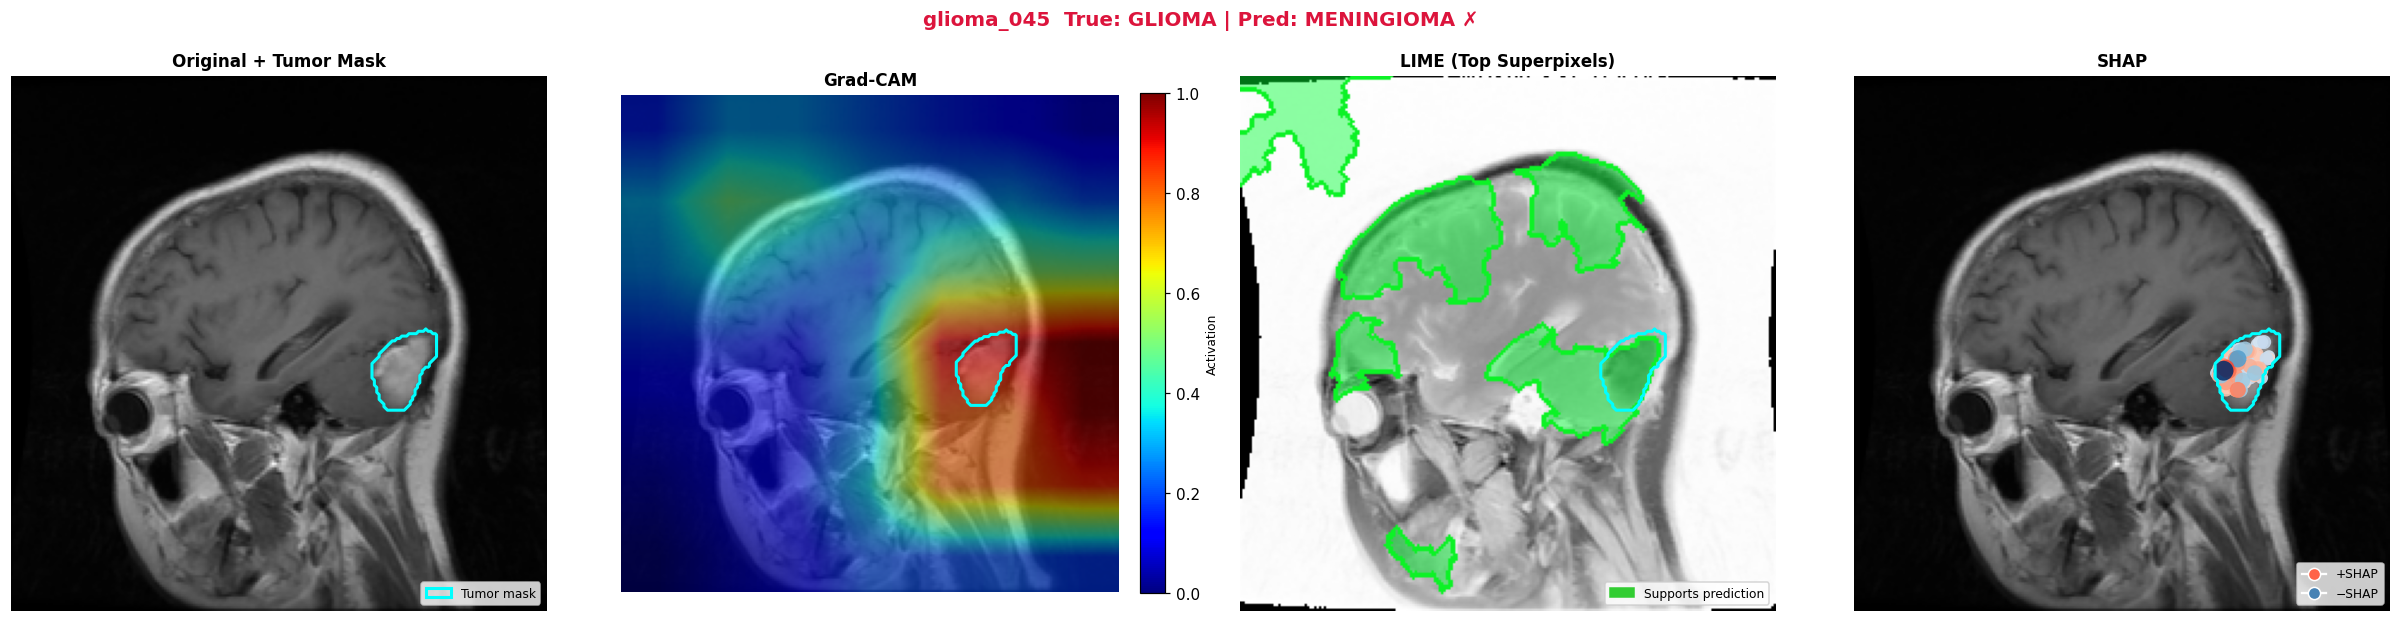


──────────────────────────────────────────────────────────────
  glioma_045 — XAI Overlap vs Tumor Mask
──────────────────────────────────────────────────────────────
  Method         IoU  Precision   Recall      F1  Overlap px
──────────────────────────────────────────────────────────────
  GradCAM     0.1182     0.1182   1.0000  0.2114         593
  SHAP        0.0946     0.0967   0.8179  0.1729         485
  LIME        0.0869     0.0886   0.8212  0.1599         487
──────────────────────────────────────────────────────────────
  Tumor mask: 593 px (1.2% of 224×224)
──────────────────────────────────────────────────────────────



In [14]:
DEMO_MAT = '/kaggle/input/datasets/userisakid/augmented-figshare-dataset/test/meningioma/MENINGIOMA_0002.mat'
# If running locally / in this notebook session, adjust path:
# DEMO_MAT = '/kaggle/working/glioma_045.mat'  # copy it there if needed

if os.path.exists(DEMO_MAT):
    pil_rgb, mask_bool = load_mat_mask(DEMO_MAT)
    print(f'Image size : {pil_rgb.size}')
    print(f'Mask shape : {mask_bool.shape if mask_bool is not None else None}')
    print(f'Tumor px   : {mask_bool.sum() if mask_bool is not None else "N/A"}')

    fig, overlap = plot_four_panel(
        pil_rgb, mask_bool,
        true_lbl      = 0,             # glioma = class index 0
        title_prefix  = 'glioma_045',
        save_path     = '/kaggle/working/xai_glioma_045.png'
    )
    print_overlap_table(overlap, title='glioma_045 — XAI Overlap vs Tumor Mask')
else:
    print(f"Demo file not found at {DEMO_MAT}")
    print("Upload glioma_045.mat to your Kaggle dataset or adjust DEMO_MAT path.")


Running XAI on 8 TEST images (2 per class)
LIME samples: 2000 | SHAP bg: 40 | thresh: 50th pct
Estimated time: ~48s GPU / ~280s CPU

[1/8] glioma — GLIOMA_0084.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_01_glioma.png


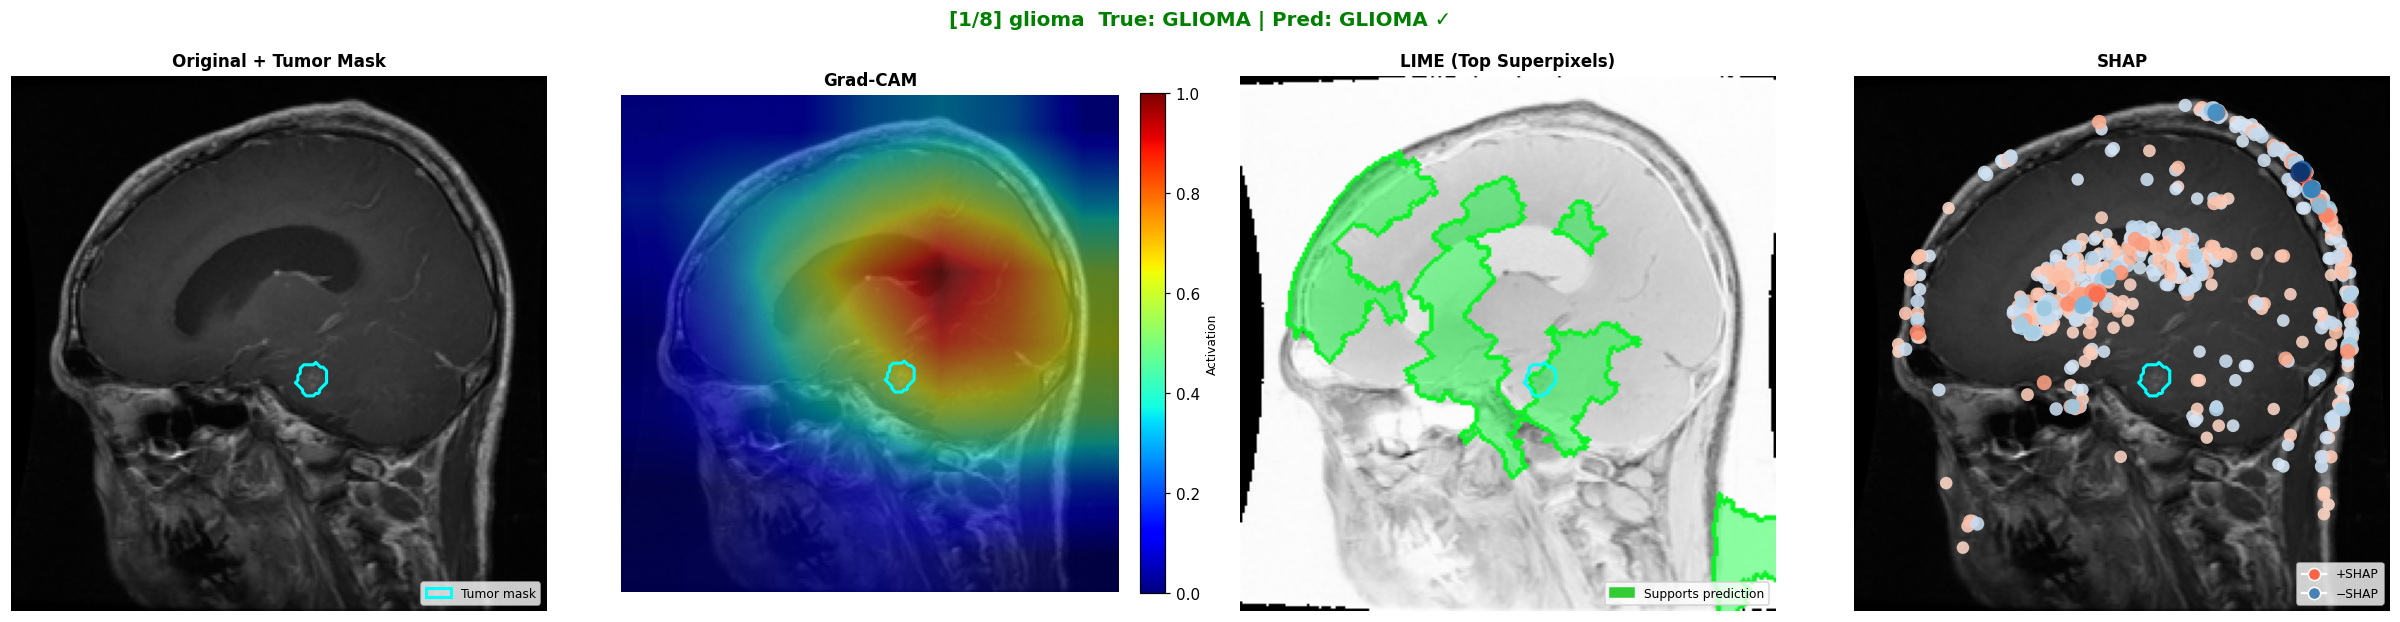


──────────────────────────────────────────────────────────────
  [1/8] glioma — GLIOMA_0084.mat
──────────────────────────────────────────────────────────────
  Method         IoU  Precision   Recall      F1  Overlap px
──────────────────────────────────────────────────────────────
  GradCAM     0.0000     0.0000   0.0000  0.0000           0
  SHAP        0.0019     0.0020   0.0787  0.0039          10
  LIME        0.0184     0.0185   0.7480  0.0362          95
──────────────────────────────────────────────────────────────
  Tumor mask: 127 px (0.3% of 224×224)
──────────────────────────────────────────────────────────────

  Done

[2/8] pituitary — PITUITARY_0017.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_02_pituitary.png


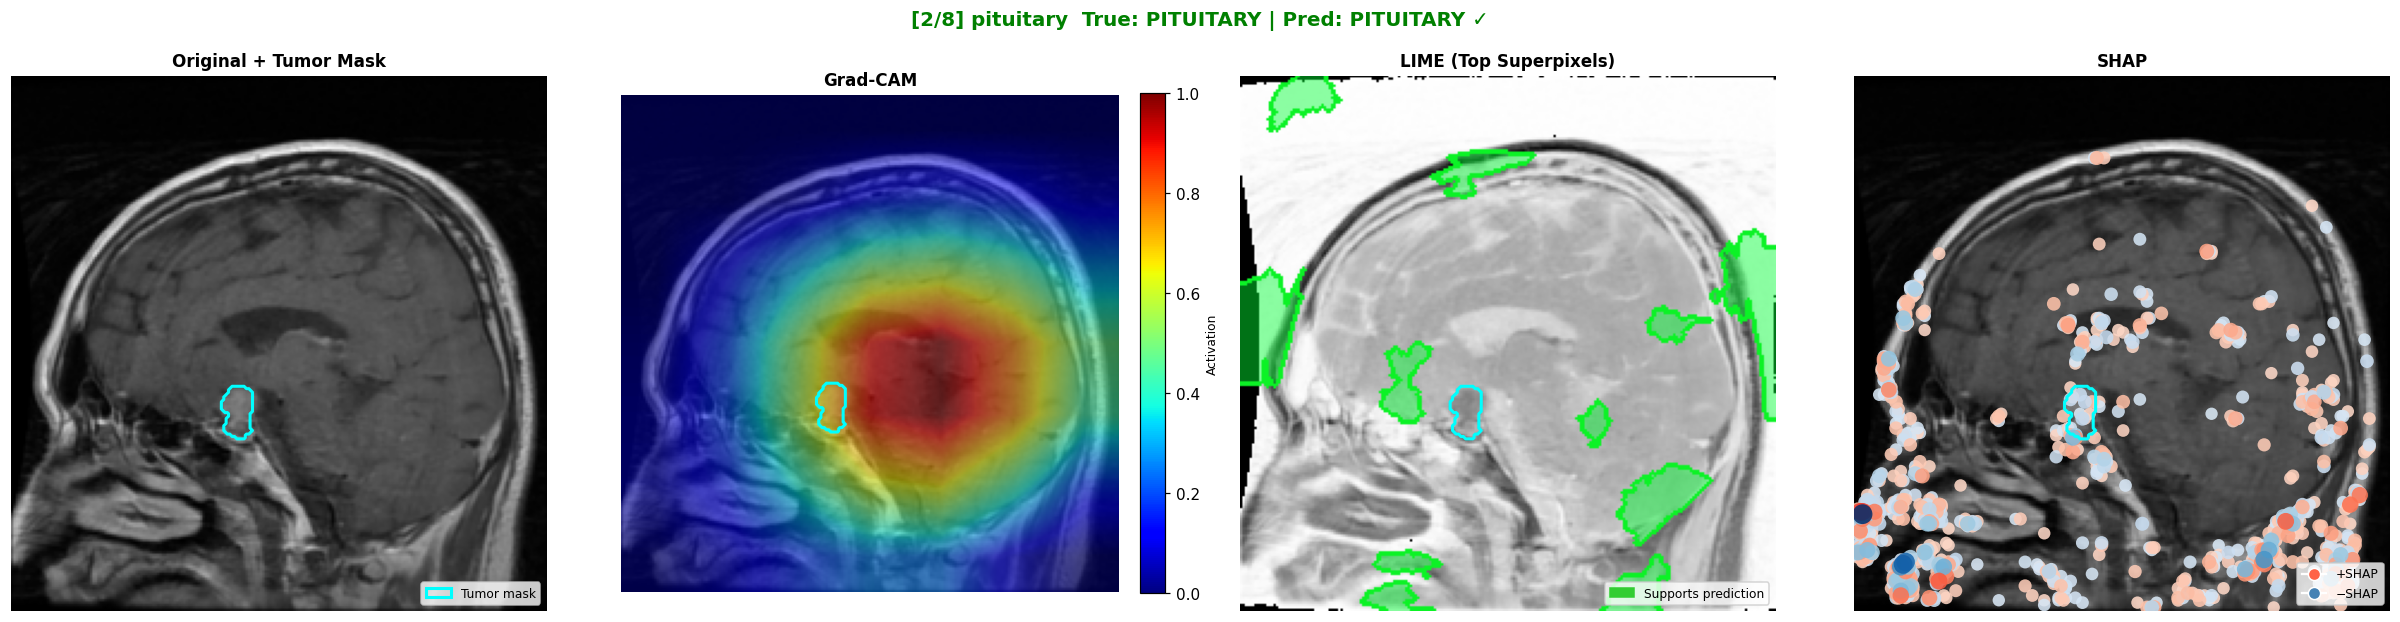


──────────────────────────────────────────────────────────────
  [2/8] pituitary — PITUITARY_0017.mat
──────────────────────────────────────────────────────────────
  Method         IoU  Precision   Recall      F1  Overlap px
──────────────────────────────────────────────────────────────
  GradCAM     0.0112     0.0116   0.2566  0.0221          58
  SHAP        0.0155     0.0159   0.3540  0.0305          80
  LIME        0.0000     0.0000   0.0000  0.0000           0
──────────────────────────────────────────────────────────────
  Tumor mask: 226 px (0.5% of 224×224)
──────────────────────────────────────────────────────────────

  Done

[3/8] pituitary — PITUITARY_0069.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_03_pituitary.png


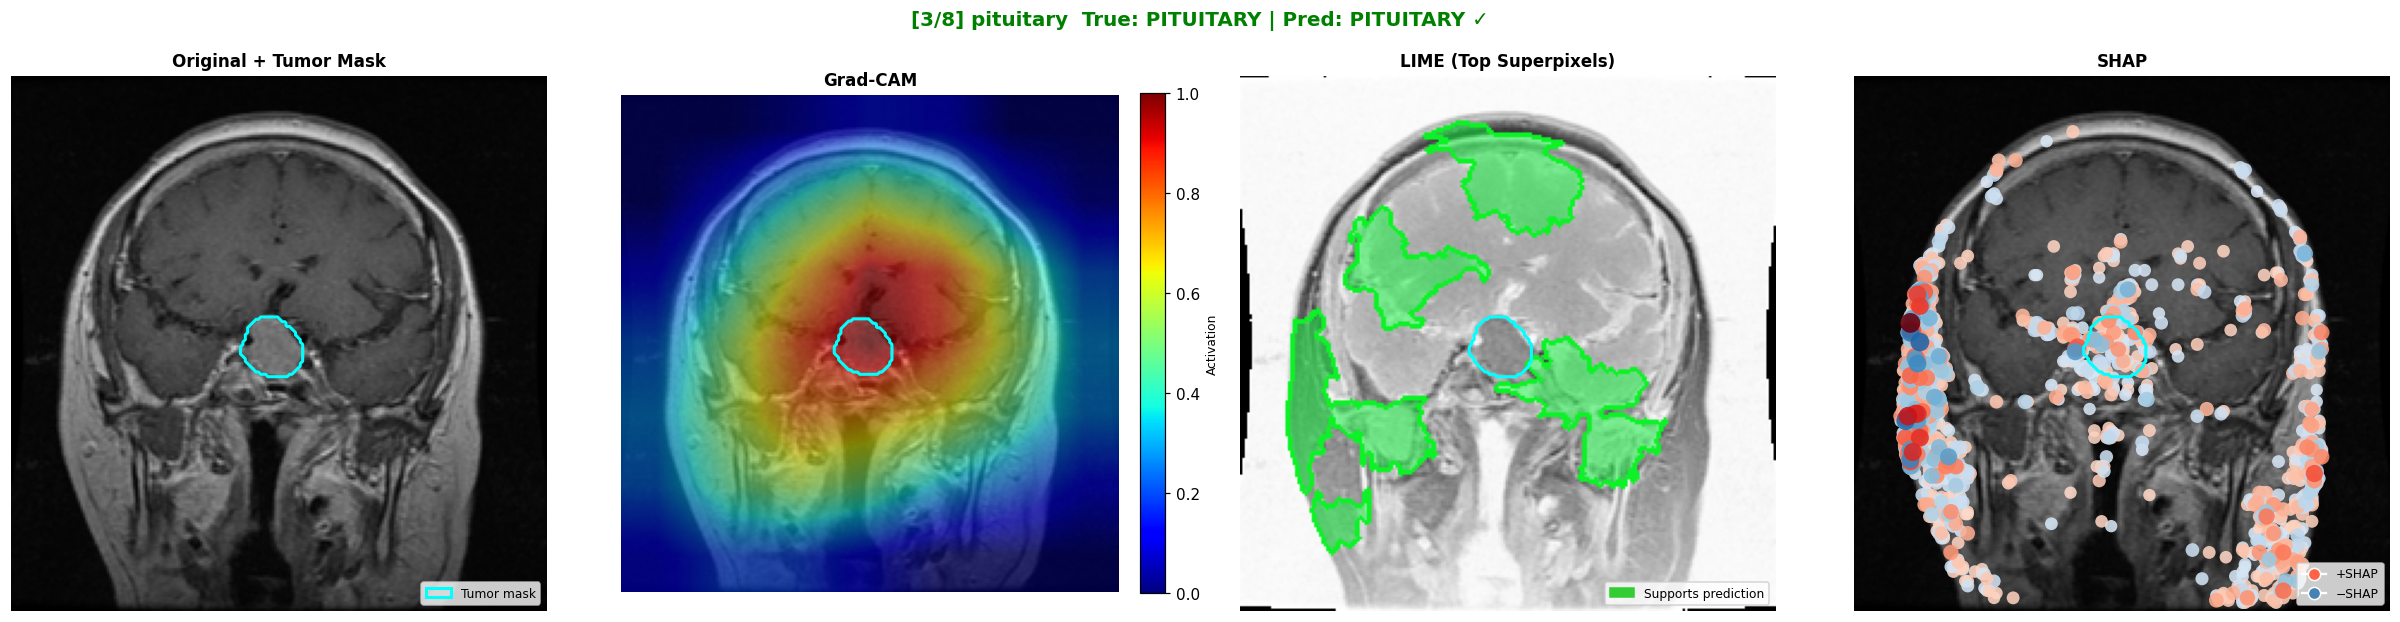


──────────────────────────────────────────────────────────────
  [3/8] pituitary — PITUITARY_0069.mat
──────────────────────────────────────────────────────────────
  Method         IoU  Precision   Recall      F1  Overlap px
──────────────────────────────────────────────────────────────
  GradCAM     0.0994     0.0994   1.0000  0.1809         499
  SHAP        0.0453     0.0476   0.4790  0.0866         239
  LIME        0.0005     0.0006   0.0060  0.0010           3
──────────────────────────────────────────────────────────────
  Tumor mask: 499 px (1.0% of 224×224)
──────────────────────────────────────────────────────────────

  Done

[4/8] glioma — GLIOMA_0015.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_04_glioma.png


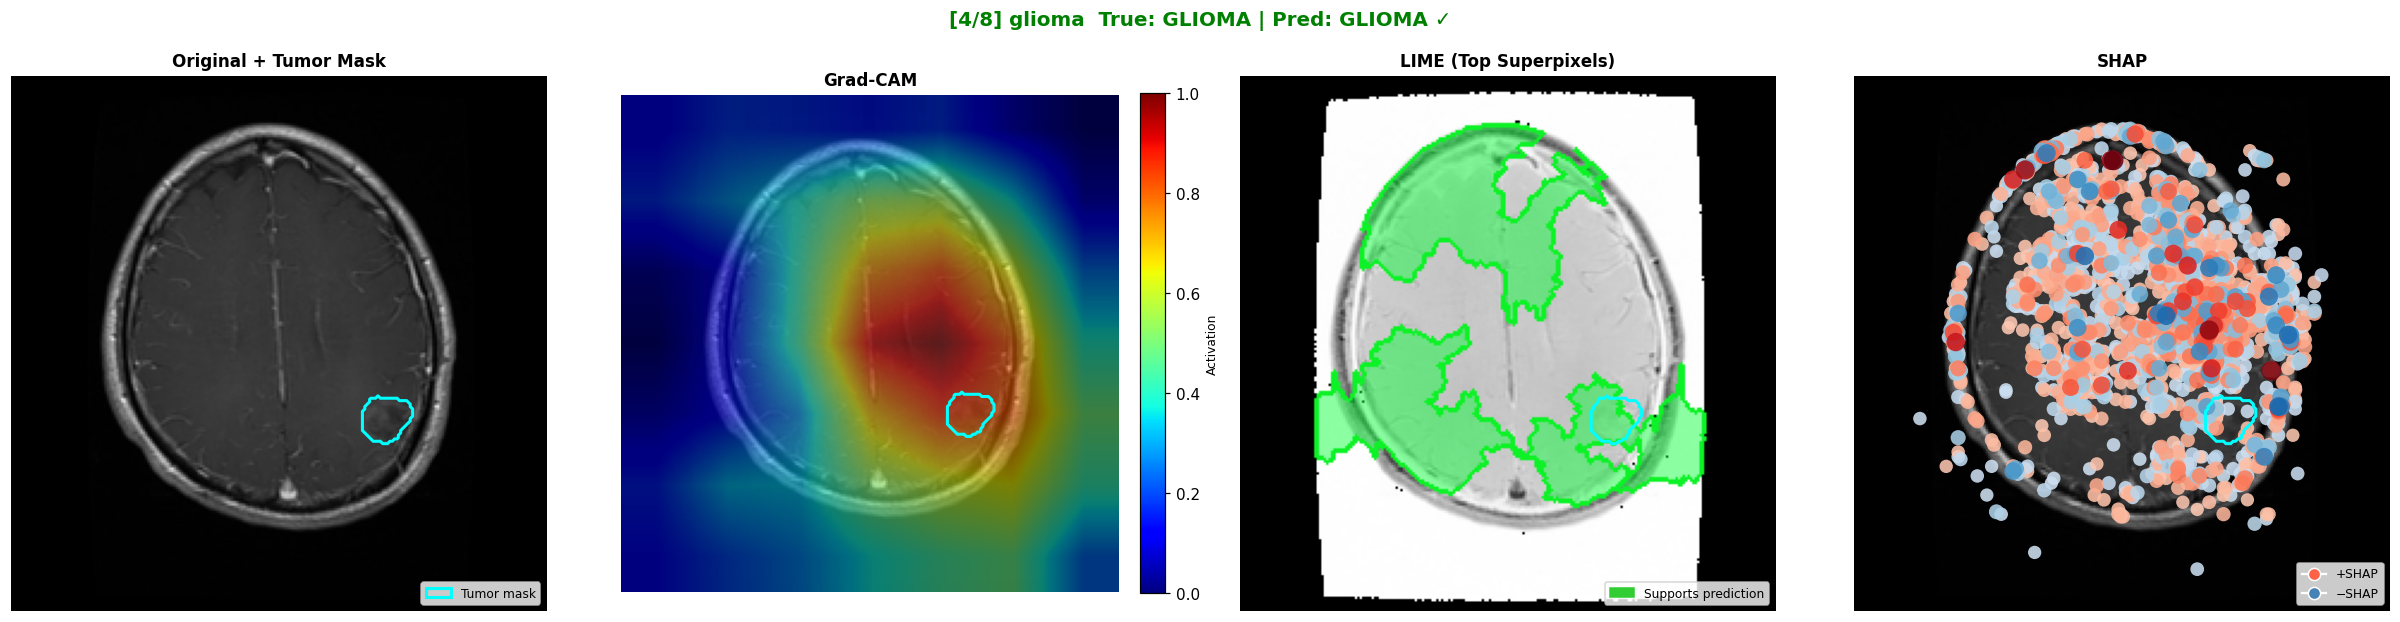


──────────────────────────────────────────────────────────────
  [4/8] glioma — GLIOMA_0015.mat
──────────────────────────────────────────────────────────────
  Method         IoU  Precision   Recall      F1  Overlap px
──────────────────────────────────────────────────────────────
  GradCAM     0.0620     0.0620   1.0000  0.1167         311
  SHAP        0.0125     0.0132   0.2122  0.0248          66
  LIME        0.0000     0.0000   0.0000  0.0000           0
──────────────────────────────────────────────────────────────
  Tumor mask: 311 px (0.6% of 224×224)
──────────────────────────────────────────────────────────────

  Done

[5/8] meningioma — MENINGIOMA_0059.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_05_meningioma.png


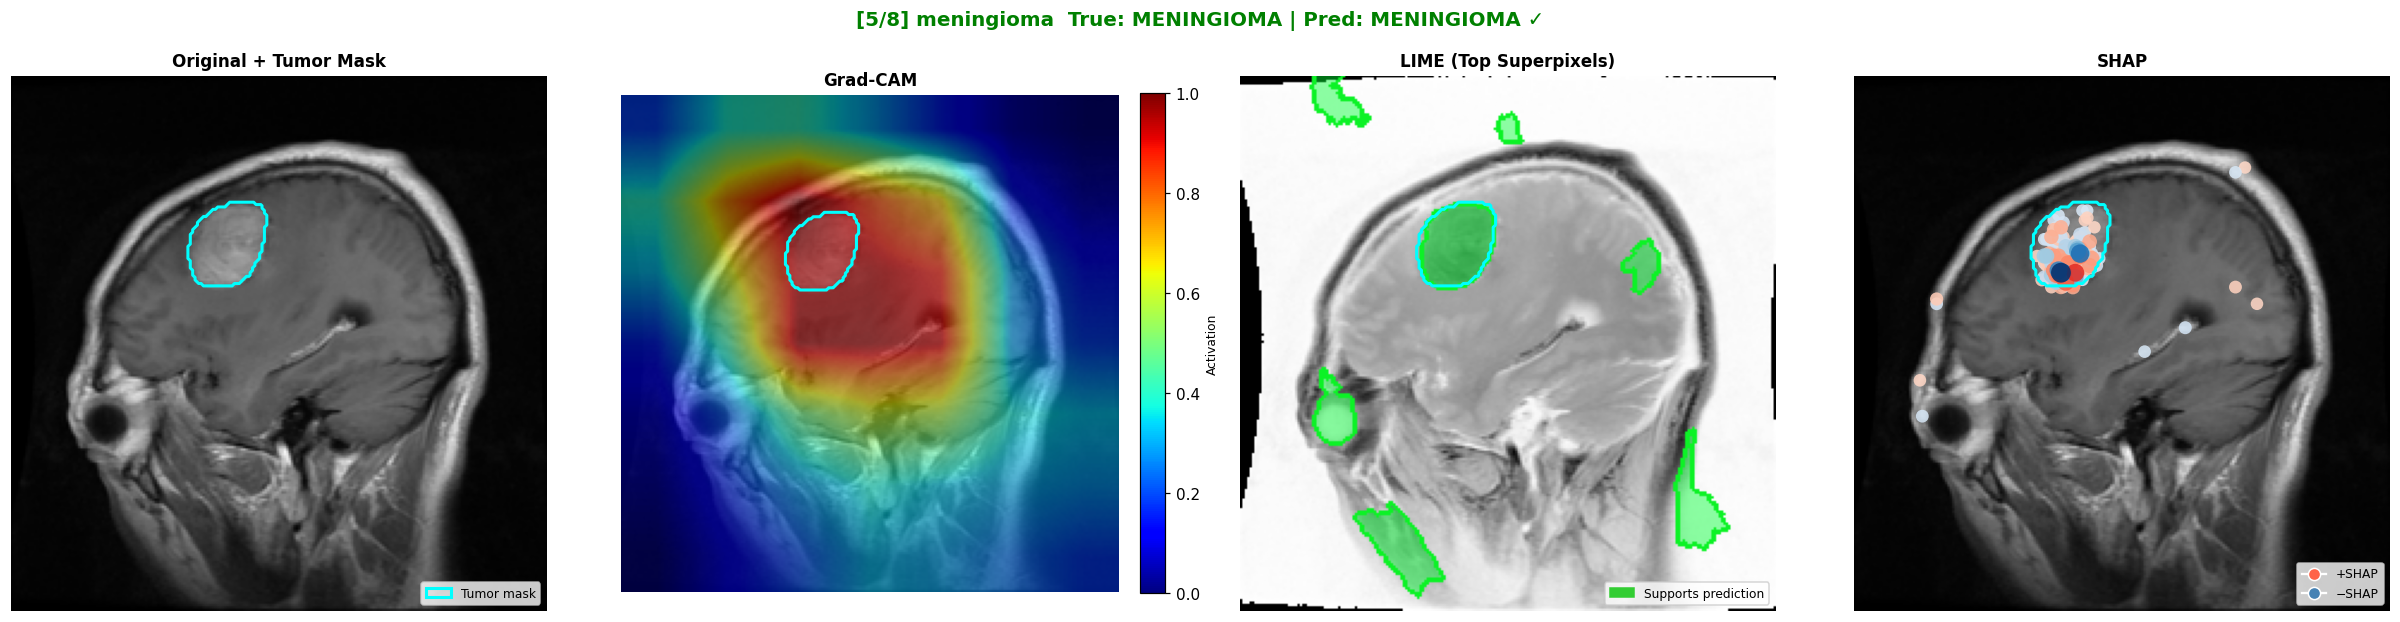


──────────────────────────────────────────────────────────────
  [5/8] meningioma — MENINGIOMA_0059.mat
──────────────────────────────────────────────────────────────
  Method         IoU  Precision   Recall      F1  Overlap px
──────────────────────────────────────────────────────────────
  GradCAM     0.1807     0.1807   1.0000  0.3062         907
  SHAP        0.1385     0.1437   0.7949  0.2434         721
  LIME        0.1584     0.1604   0.9250  0.2734         839
──────────────────────────────────────────────────────────────
  Tumor mask: 907 px (1.8% of 224×224)
──────────────────────────────────────────────────────────────

  Done

[6/8] no_tumor — NO_TUMOR_0103.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_06_no_tumor.png


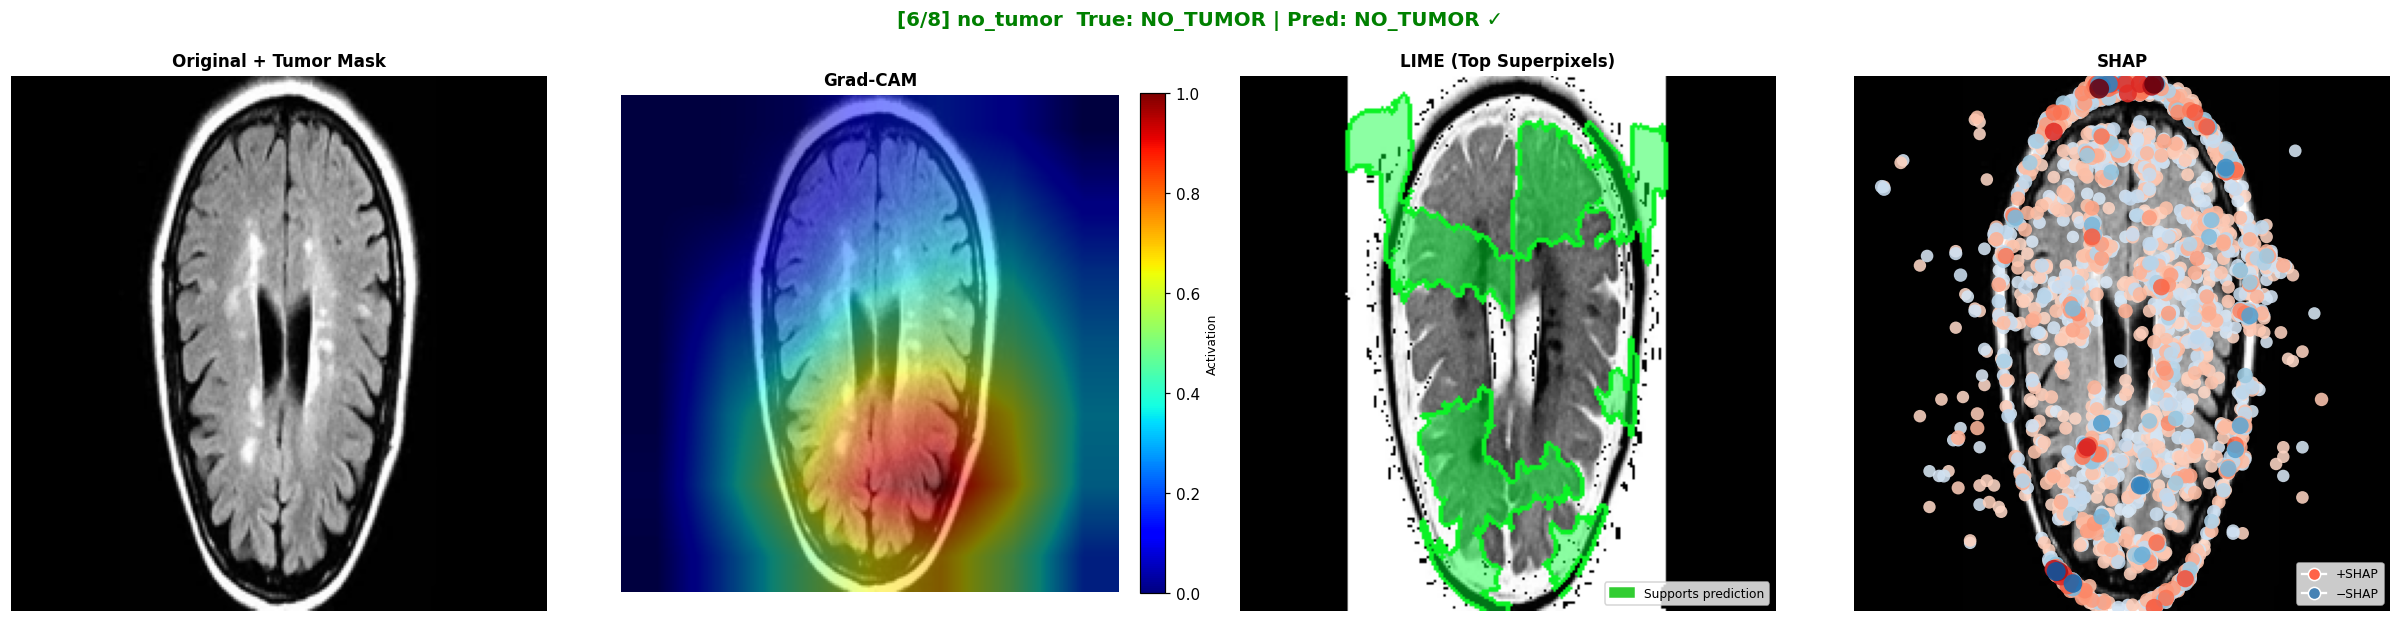

No ground-truth mask available — skipping overlap analysis.
  Done

[7/8] no_tumor — NO_TUMOR_0081.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_07_no_tumor.png


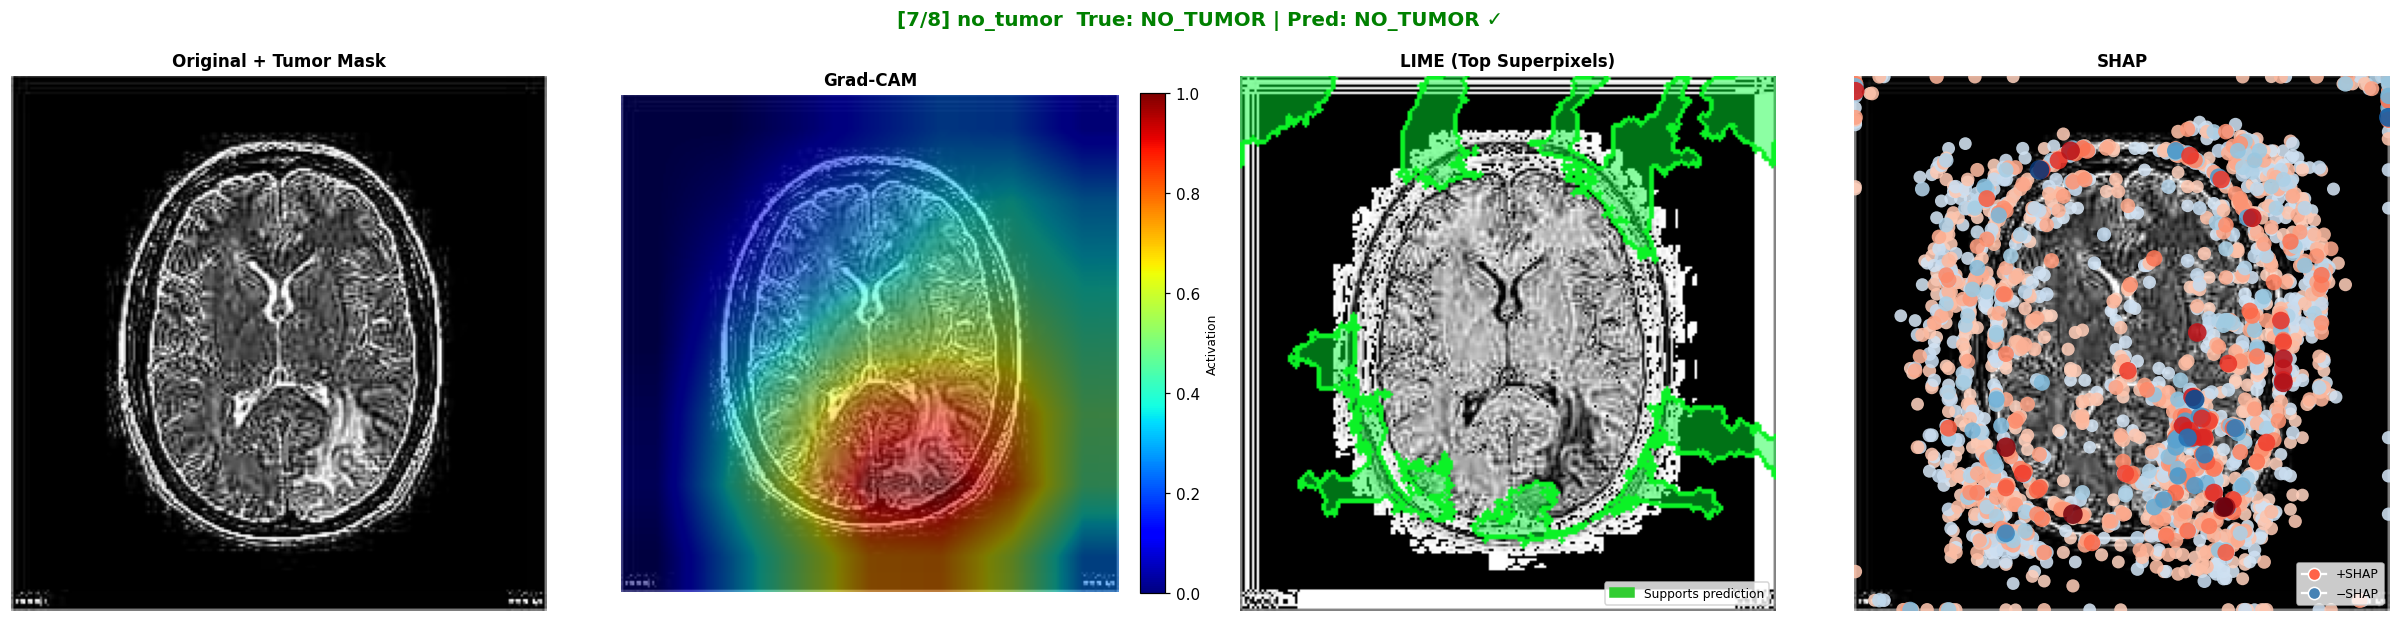

No ground-truth mask available — skipping overlap analysis.
  Done

[8/8] meningioma — MENINGIOMA_0009.mat


  0%|          | 0/2000 [00:00<?, ?it/s]

  Saved → /kaggle/working/xai_08_meningioma.png


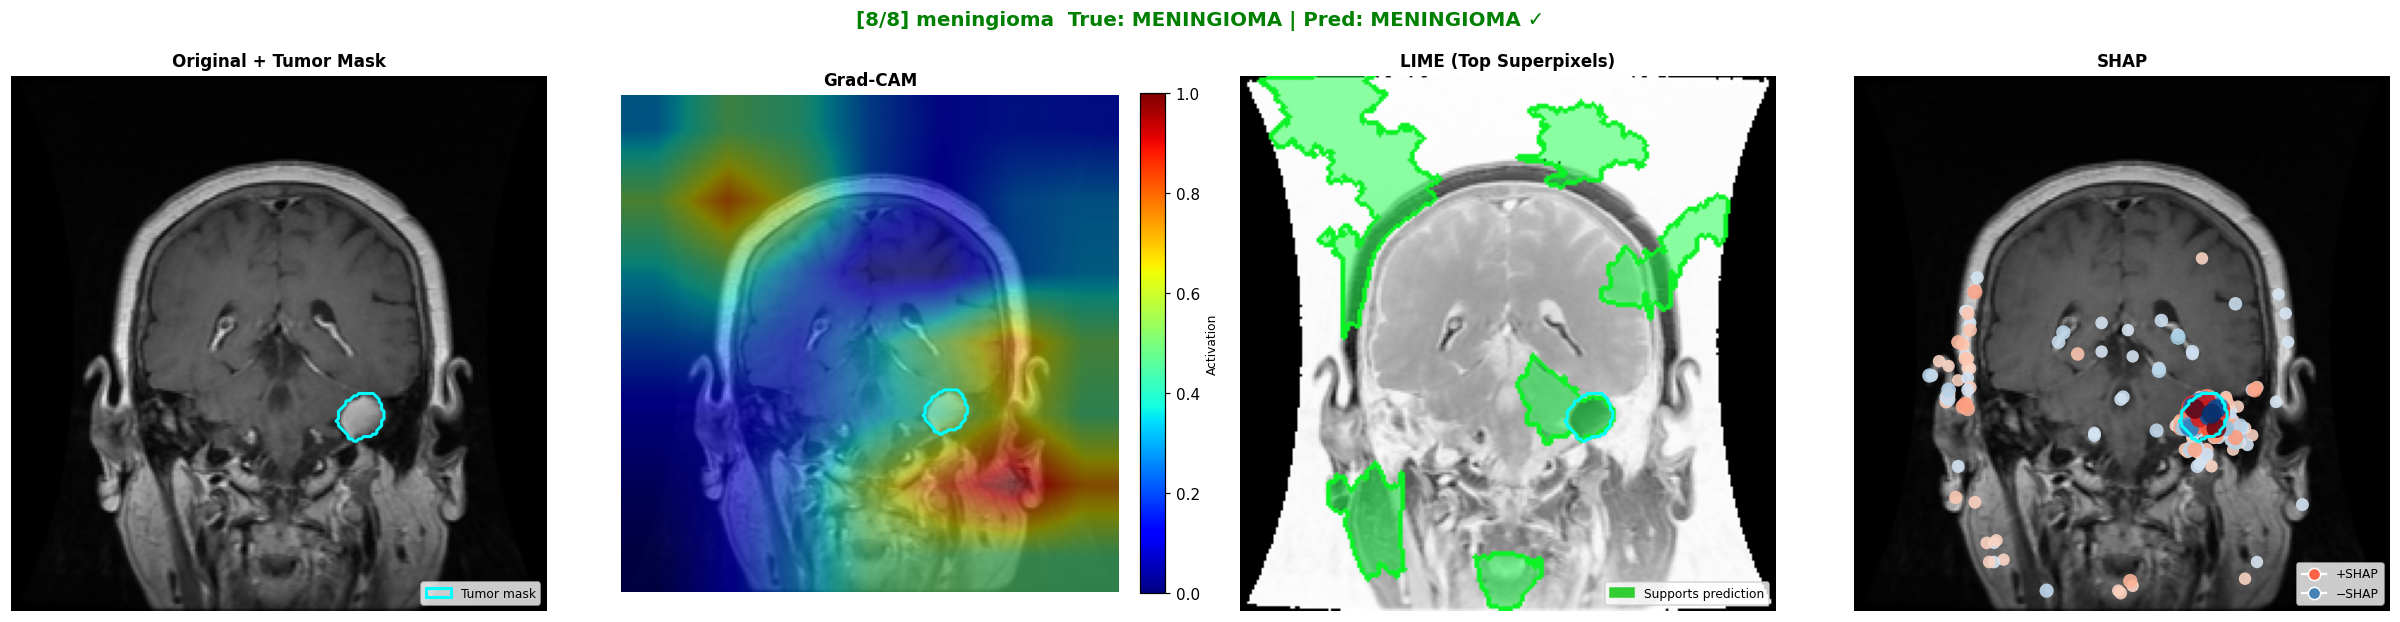


──────────────────────────────────────────────────────────────
  [8/8] meningioma — MENINGIOMA_0009.mat
──────────────────────────────────────────────────────────────
  Method         IoU  Precision   Recall      F1  Overlap px
──────────────────────────────────────────────────────────────
  GradCAM     0.0000     0.0000   0.0000  0.0000           0
  SHAP        0.0449     0.0454   0.8057  0.0860         228
  LIME        0.0488     0.0492   0.8728  0.0931         247
──────────────────────────────────────────────────────────────
  Tumor mask: 283 px (0.6% of 224×224)
──────────────────────────────────────────────────────────────

  Done

XAI grid complete.


In [15]:
all_overlaps    = []
all_class_names = []

def run_full_xai(n_per_class=N_PER_CLASS):
    sampled = sample_balanced(n_per_class)
    n       = len(sampled)
    print(f'Running XAI on {n} TEST images ({n_per_class} per class)')
    print(f'LIME samples: {LIME_NUM_SAMPLES} | SHAP bg: {SHAP_BG_SIZE} | thresh: {SALIENCY_THRESH*100:.0f}th pct')
    print(f'Estimated time: ~{n*6}s GPU / ~{n*35}s CPU\n')

    for idx, (fpath, true_lbl) in enumerate(sampled):
        cls_name = CLASS_NAMES[true_lbl]
        print(f'[{idx+1}/{n}] {cls_name} — {os.path.basename(fpath)}')
        try:
            pil_rgb, mask_bool = load_mat_mask(fpath)
            save_p = f'/kaggle/working/xai_{idx+1:02d}_{cls_name}.png'

            fig, overlap = plot_four_panel(
                pil_rgb, mask_bool,
                true_lbl     = true_lbl,
                title_prefix = f'[{idx+1}/{n}] {cls_name}',
                save_path    = save_p,
            )
            plt.close(fig)

            print_overlap_table(
                overlap,
                title=f'[{idx+1}/{n}] {cls_name} — {os.path.basename(fpath)}'
            )

            all_overlaps.append(overlap)
            all_class_names.append(cls_name)
            print(f'  Done\n')

        except Exception as e:
            import traceback
            print(f'  ERROR: {e}')
            traceback.print_exc()
            all_overlaps.append(None)
            all_class_names.append(cls_name)

    print('XAI grid complete.')


run_full_xai()


In [16]:
methods = ['GradCAM', 'SHAP', 'LIME']
metrics = ['iou', 'precision', 'recall', 'f1']

valid_overlaps = [ov for ov in all_overlaps if ov is not None]
print(f'Valid results: {len(valid_overlaps)} / {len(all_overlaps)} images\n')

# ── Per-method aggregated stats ───────────────────────────────────────────────
rows = []
for method in methods:
    row = {'Method': method}
    for met in metrics:
        vals = [ov[method][met] for ov in valid_overlaps]
        row[f'{met}_mean'] = np.mean(vals)
        row[f'{met}_std']  = np.std(vals)
        row[f'{met}_min']  = np.min(vals)
        row[f'{met}_max']  = np.max(vals)
    rows.append(row)

df_agg = pd.DataFrame(rows).set_index('Method')
pd.set_option('display.float_format', '{:.4f}'.format)
print("=== Aggregated Overlap Metrics (mean ± std) ===")
print(df_agg[[c for c in df_agg.columns if '_mean' in c or '_std' in c]])
print()
print("=== Min / Max ===")
print(df_agg[[c for c in df_agg.columns if '_min' in c or '_max' in c]])

df_agg.to_csv('/kaggle/working/overlap_aggregated.csv')
print('\nSaved → /kaggle/working/overlap_aggregated.csv')


Valid results: 6 / 8 images

=== Aggregated Overlap Metrics (mean ± std) ===
         iou_mean  iou_std  precision_mean  precision_std  recall_mean  \
Method                                                                   
GradCAM    0.0589   0.0655          0.0590         0.0654       0.5428   
SHAP       0.0431   0.0457          0.0446         0.0474       0.4541   
LIME       0.0377   0.0567          0.0381         0.0574       0.4253   

         recall_std  f1_mean  f1_std  
Method                                
GradCAM      0.4652   0.1043  0.1120  
SHAP         0.2738   0.0792  0.0796  
LIME         0.4266   0.0673  0.0980  

=== Min / Max ===
         iou_min  iou_max  precision_min  precision_max  recall_min  \
Method                                                                
GradCAM   0.0000   0.1807         0.0000         0.1807      0.0000   
SHAP      0.0019   0.1385         0.0020         0.1437      0.0787   
LIME      0.0000   0.1584         0.0000         0.160

Saved bar chart → /kaggle/working/overlap_bar_chart.png


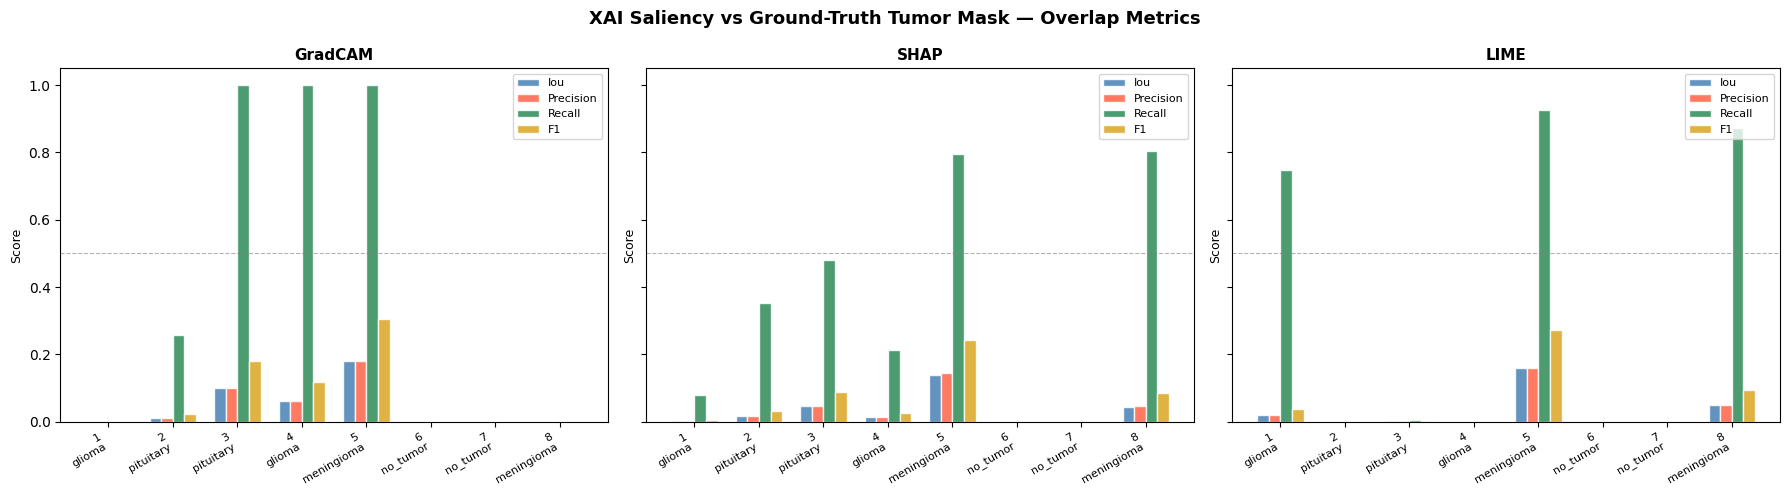

In [17]:
plot_overlap_bars(
    all_overlaps,
    all_class_names,
    save_path='/kaggle/working/overlap_bar_chart.png'
)


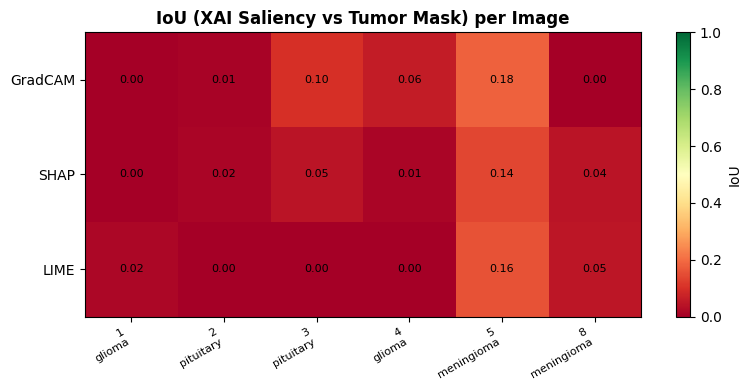

Saved → /kaggle/working/iou_heatmap.png


In [18]:
fig, ax = plt.subplots(figsize=(max(8, len(valid_overlaps)*0.7), 4), dpi=100)

iou_matrix = np.array([
    [ov[m]['iou'] for m in methods]
    for ov in all_overlaps if ov is not None
]).T   # shape (3, n_images)

labels_x = [f'{i+1}\n{all_class_names[j]}'
             for i,j in enumerate(range(len(all_class_names))) if all_overlaps[j] is not None]

im = ax.imshow(iou_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(range(len(methods))); ax.set_yticklabels(methods, fontsize=10)
ax.set_xticks(range(len(labels_x))); ax.set_xticklabels(labels_x, fontsize=8, rotation=30, ha='right')

for i in range(len(methods)):
    for j in range(iou_matrix.shape[1]):
        ax.text(j, i, f'{iou_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8)

plt.colorbar(im, ax=ax, label='IoU')
ax.set_title('IoU (XAI Saliency vs Tumor Mask) per Image', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/iou_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved → /kaggle/working/iou_heatmap.png')


In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def run_upload_ui():
    upload_w    = widgets.FileUpload(
        accept='.mat,.jpg,.jpeg,.png', multiple=False,
        description='Upload MRI', layout=widgets.Layout(width='280px')
    )
    predict_btn = widgets.Button(
        description='▶ Run XAI', button_style='success',
        layout=widgets.Layout(width='130px')
    )
    output_area = widgets.Output()

    def on_predict(b):
        with output_area:
            clear_output(wait=True)
            files = upload_w.value
            if not files:
                print('Please upload a file first.')
                return
            items = [(f['name'], bytes(f['content'])) for f in files] \
                    if isinstance(files, tuple) \
                    else [(n, bytes(i['content'])) for n, i in files.items()]

            for filename, raw in items:
                print(f'Processing: {filename} …')
                try:
                    pil_rgb, mask_bool = load_mat_mask(raw, filename)
                    save_p = f'/kaggle/working/upload_{filename}.png'
                    fig, overlap = plot_four_panel(
                        pil_rgb, mask_bool,
                        title_prefix=f'Upload: {filename}',
                        save_path=save_p
                    )
                    print_overlap_table(overlap, title=filename)
                except Exception as e:
                    import traceback
                    print(f'Error on {filename}:')
                    traceback.print_exc()

    predict_btn.on_click(on_predict)
    print('Upload a .mat / .jpg / .png then click ▶ Run XAI')
    display(widgets.HBox([upload_w, predict_btn]))
    display(output_area)


run_upload_ui()


Upload a .mat / .jpg / .png then click ▶ Run XAI


Output()